<a href="https://colab.research.google.com/github/kanchan874/Machine_vision/blob/main/Practical04_MV_CM23004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import files

uploaded = files.upload()

Saving Surface-defect-detection.webp to Surface-defect-detection.webp


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

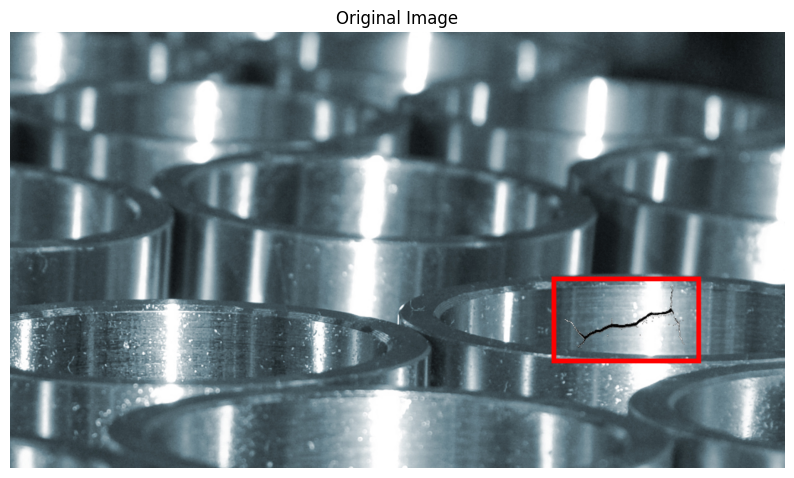

In [15]:
image = cv2.imread("Surface-defect-detection.webp")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

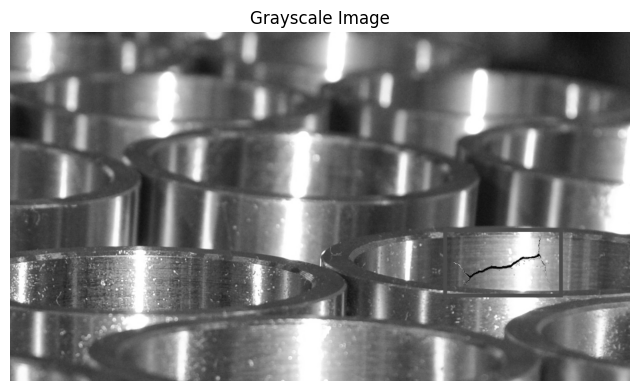

In [16]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8,6))
plt.imshow(gray,cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

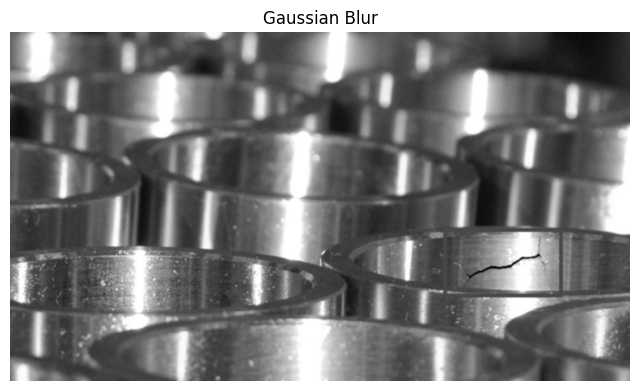

In [17]:
blur = cv2.GaussianBlur(gray,(5,5),0)

plt.figure(figsize=(8,6))
plt.imshow(blur,cmap='gray')
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

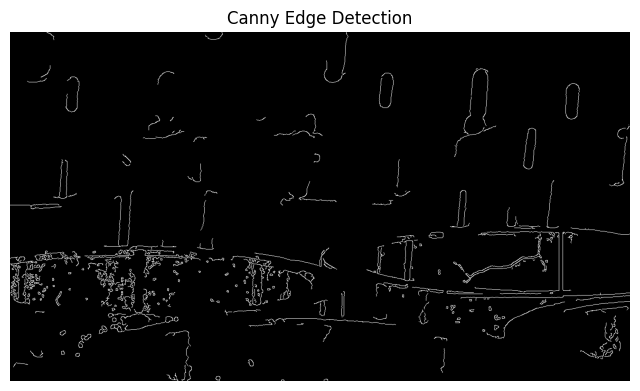

In [18]:
edges = cv2.Canny(blur,50,150)

plt.figure(figsize=(8,6))
plt.imshow(edges,cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

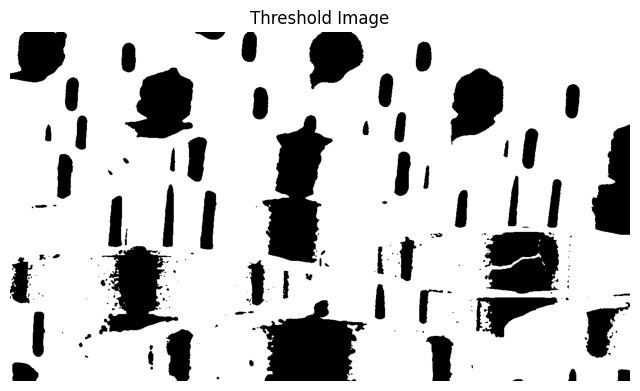

In [19]:
_,thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU
)

plt.figure(figsize=(8,6))
plt.imshow(thresh,cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

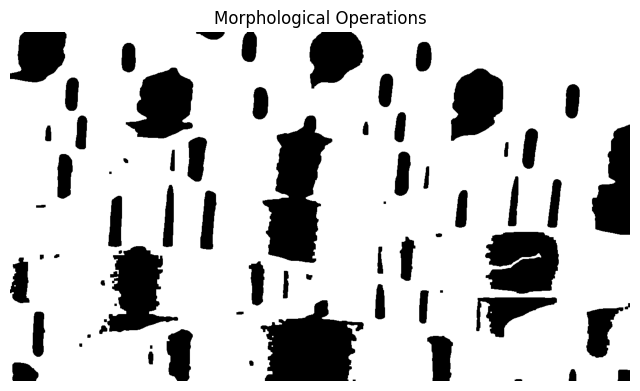

In [20]:
kernel=np.ones((3,3),np.uint8)

opening=cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

closing=cv2.morphologyEx(
    opening,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

plt.figure(figsize=(8,6))
plt.imshow(closing,cmap='gray')
plt.title("Morphological Operations")
plt.axis("off")
plt.show()

Detected Defects : 2


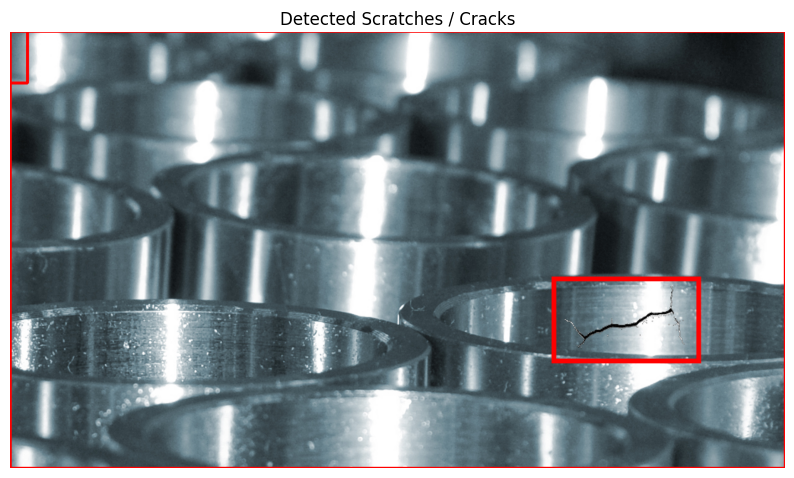

In [21]:
contours,_=cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

result=image.copy()

count=0

for cnt in contours:

    area=cv2.contourArea(cnt)

    if area>150:

        x,y,w,h=cv2.boundingRect(cnt)

        cv2.rectangle(
            result,
            (x,y),
            (x+w,y+h),
            (255,0,0),
            3
        )

        count+=1

print("Detected Defects :",count)

plt.figure(figsize=(10,6))
plt.imshow(result)
plt.title("Detected Scratches / Cracks")
plt.axis("off")
plt.show()

In [22]:
areas=[]

for cnt in contours:

    area=cv2.contourArea(cnt)

    if area>150:
        areas.append(area)

print("Number of Defects :",len(areas))
print("Area of Defects :",areas)

Number of Defects : 2
Area of Defects : [883454.0, 1556.0]


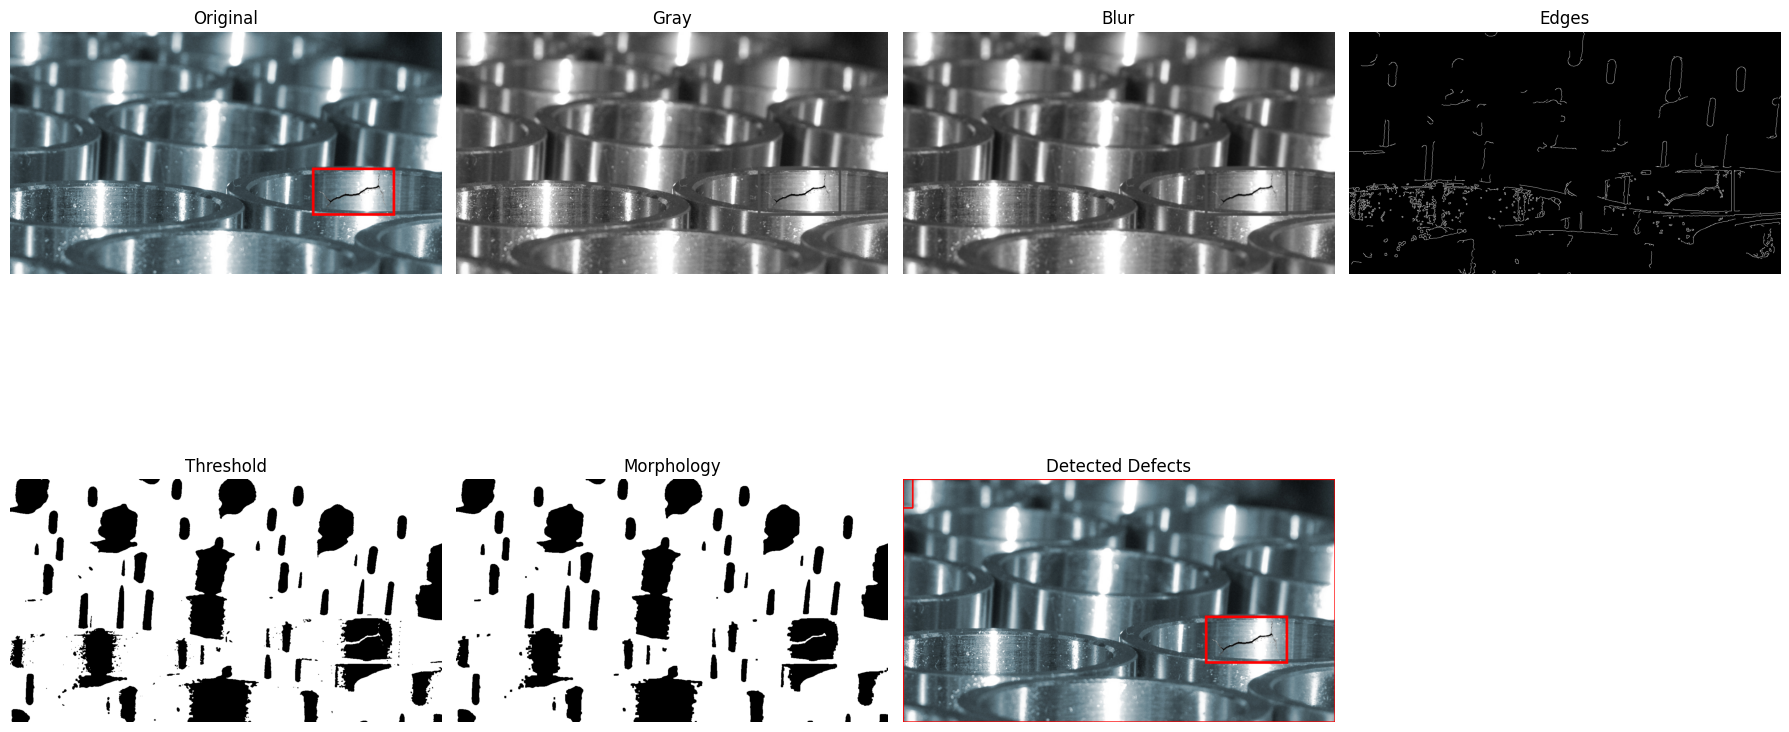

In [23]:
titles=[
    "Original",
    "Gray",
    "Blur",
    "Edges",
    "Threshold",
    "Morphology",
    "Detected Defects"
]

images=[
    image,
    gray,
    blur,
    edges,
    thresh,
    closing,
    result
]

plt.figure(figsize=(18,10))

for i in range(len(images)):

    plt.subplot(2,4,i+1)

    if len(images[i].shape)==2:
        plt.imshow(images[i],cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()